# European option price

---


## Objective:

To compute and compare European option prices using Black-Scholes, Binomial, and Monte Carlo methods.

---

## Methodology:

- Implemented the Black-Scholes model as a benchmark.
- Used a discrete-time Binomial tree model and stochastic Monte Carlo simulation.
- Conducted convergence and error analysis for Monte Carlo using log-log plots against theoretical error.

---

## Key Findings:  

- All methods provided consistent option price estimates.
- Monte Carlo simulation showed error convergence at the expected rate of $1/\sqrt{N}$.
- Black-Scholes was computationally efficient for European options, while Monte Carlo offered flexibility for more complex structures.

---

## Conclusion:

The project validated the theoretical convergence rate of Monte Carlo simulations and highlighted trade-offs between accuracy and computation time among different pricing methods.

---


Required packages:

In [1]:
import numpy as np
from scipy.stats import norm
import math
import matplotlib.pyplot as plt

Function to calculate option value using Black Scholes formula

In [2]:
def black_scholes_option_pricing(S0,K,T,r,sigma,option_type='call'):
    """
    European option price via Black Scholes model

    Parameters:
    S0: Initial stock price (float)
    K: Strike price (float)
    T: Time to maturity (float)
    r: Risk free interest rate (float)
    sigma: Volatility of the asset (float)
    option_type: Type of the option 'call' or 'put' (str)

    Returns: The price of the option (float)
    """
    
    # calculate d1 and d2
    d1=(np.log(S0/K)+(r+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2=d1-sigma*np.sqrt(T)
    
    # option value
    if option_type=='call':
        bs_option_value=S0*norm.cdf(d1)-K*np.exp(-r*T)*norm.cdf(d2)
    elif option_type=='put':
        bs_option_value=K*np.exp(-r*T)*norm.cdf(-d2)-S0*norm.cdf(-d1)
    
    return bs_option_value

Function to calculatte option price using binomial method

In [3]:
def binomial_option_pricing(S0,K,T,r,sigma,N,option_type='call'):
    """
    European option price via binomial model
    
    Parameters:
    S0 : Initial asset price (float)
    K : Strike price (float)
    T : Maturity time in years (float)
    r : Risk free interest rate (float)
    sigma : Volatility of the asset (float)
    N : Number of steps in the binomial tree model (int)
    option_type : Type of the option 'call' or 'put' (str)
    
    Returns: The price of the option (float)
    """

    
    dt=T/N
    u=np.exp(sigma * np.sqrt(dt))
    d=1/u
    
    # risk-neutral probability
    p=(np.exp(r*dt)-d)/(u-d)
    
    # computing asset prices and corresponding probabilities at the last step
    asset_prices=np.array([S0*u**(N-i)*d**i for i in range(0,N+1)])
    asset_prob=np.array([math.comb(N,i)* p**(N-i)*(1-p)**i for i in range(0,N+1)])

    # net payoff values at last step
    if option_type=='call':
        payoff_values=np.maximum(0,asset_prices-K)
    elif option_type=='put':
        payoff_values=np.maximum(0,K-asset_prices)

    # option price
    bi_option_value=np.exp(-r*T)*np.dot(payoff_values,asset_prob)
    
    return bi_option_value
    

## Note:

Expected theoretical error of Monte Carlo mehod given by:

$$ \frac{e^{-rT} \sigma_{\mathrm{payoff}}}{\sqrt{N}} $$

where:

- $r$ is the risk-free rate.
- $T$ is the time to maturity.
- $\sigma_{\mathrm{payoff}}$ is the standard deviation of simulated payoffs.
- $N$ is the number of Monte Carlo simulations.
A log-log plot was used to confirm the expected convergence rate.

Function to calculate option price using Monte Carlo simulations

In [26]:
def monte_carlo_option_pricing(S0,K,T,r,sigma,N,num_sim,option_type='call'):
    """
    European option price via Monte Carlo simulations

    Parameters:
    S0: Initial stock price (float)
    K: Strike price (float)
    T: Time to maturity (float)
    r: Risk free interest rate (float)
    sigma: Volatility of the asset (float)
    N: Number of time steps (int)
    num_sim: Number of simulations (int)
    option_type: Type of the option 'call' or 'put' (str)

    Returns: The price of the option (float) and  theoretical error (float)
    """

    np.random.seed(10)
    # time step
    dt=T/N
    # simulation of the asset price
    asset_path=np.zeros((num_sim,N+1))
    asset_path[:,0]=S0
    for i in range(1,N+1):
        Z=np.random.standard_normal(num_sim)
        asset_path[:,i]=asset_path[:,i-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z)
    if option_type=='call':
        payoffs=np.maximum(asset_path[:,-1]-K,0)
    elif option_type=='put':
        payoffs=np.maximum(K-asset_path[:,-1],0)

    # option price
    mc_option_value=np.exp(-r*T)*np.mean(payoffs)

    error_theo=np.exp(-r*T)*payoffs.std()/(num_sim**0.5)
    
    return mc_option_value,error_theo

An example

In [33]:

S0=200   # Initial stock price
K=210   # Strike price
T=0.5      # Maturity time (6 months)
r=0.05   # Risk-free interest rate (5% per annum)
sigma=0.15  # Volatility (15% per annum)
N=round(T*365)   # Number of steps
num_sim=10000 # Number of simulations

bs_call_price=black_scholes_option_pricing(S0,K,T,r,sigma,option_type='call')
bs_put_price=black_scholes_option_pricing(S0,K,T,r,sigma,option_type='put')

bi_call_price=binomial_option_pricing(S0,K,T,r,sigma,N,option_type='call')
bi_put_price = binomial_option_pricing(S0,K,T,r,sigma,N,option_type='put')

mc_call_price,_=monte_carlo_option_pricing(S0,K,T,r,sigma,N,num_sim,option_type='call')
mc_put_price,_=monte_carlo_option_pricing(S0,K,T,r,sigma,N,num_sim,option_type='put')


print(f"Black Scholes model: Call option price: {bs_call_price:.3f} and Put option price: {bs_put_price:.3f}")
print(f"Binomial model: Call option price: {bi_call_price:.3f} and Put option price: {bi_put_price:.3f}")
print(f"Monte Carlo method: Call option price: {mc_call_price:.3f} and Put option price: {mc_put_price:.3f}")


Black Scholes model: Call option price: 6.367 and Put option price: 11.182
Binomial model: Call option price: 6.362 and Put option price: 11.177
Monte Carlo method: Call option price: 6.256 and Put option price: 11.325


## Part II: Monte Carlo method's error analysis

---

In [28]:
num_sim_arr=np.linspace(100, 10**5, 100, dtype=int)

mc_call_price_arr=[]
error_theo_arr=[]
for num in num_sim_arr:
    price,error=monte_carlo_option_pricing(S0,K,T,r,sigma,N,num,option_type='call')
    mc_call_price_arr.append(price)
    error_theo_arr.append(error)
    

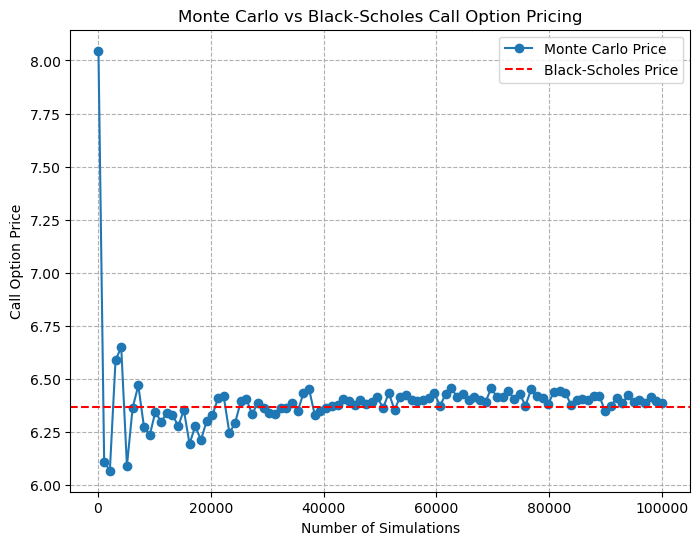

In [29]:
plt.figure(figsize=(8, 6))
plt.plot(num_sim_arr,mc_call_price_arr,label="Monte Carlo Price", marker='o', linestyle='-')
plt.axhline(y=bs_call_price, color='r', linestyle='--', label="Black-Scholes Price")
plt.xlabel("Number of Simulations")
plt.ylabel("Call Option Price")
plt.title("Monte Carlo vs Black-Scholes Call Option Pricing")
plt.legend()
plt.grid(True, linestyle='--')
plt.show()

In [30]:
error_observed=[abs(bs_call_price-x) for x in mc_call_price_arr]

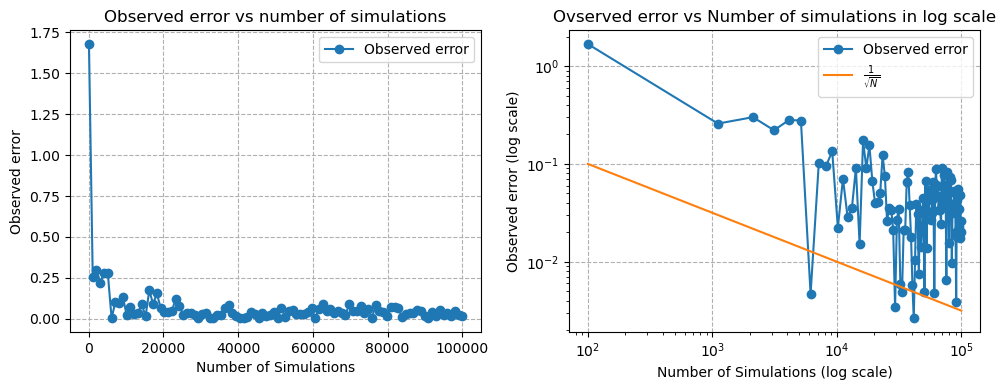

In [31]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4)) 

ax[0].plot(num_sim_arr,error_observed,marker='o',label="Observed error")
ax[0].set_xlabel("Number of Simulations")
ax[0].set_ylabel("Observed error")
ax[0].set_title("Observed error vs number of simulations")
ax[0].legend()
ax[0].grid(True, linestyle='--')

ax[1].loglog(num_sim_arr, error_observed, linestyle='-', marker="o", label="Observed error")
ax[1].loglog(num_sim_arr, [1/(x**0.5) for x in num_sim_arr], label=r"$\frac{1}{\sqrt{N}}$")
ax[1].legend()
ax[1].grid(True, linestyle='--')
ax[1].set_xlabel("Number of Simulations (log scale)")
ax[1].set_ylabel("Observed error (log scale)")
ax[1].set_title("Ovserved error vs Number of simulations in log scale")

plt.tight_layout()
plt.show()

Conclusions from the figures:
- The first figure shows that the error decreases significantly as the number of simulations reaches $10^5$. Beyond this point, the error stabilizes.
- The second figure, plotted on a log-log scale, suggests that the error is proportional to $\frac{1}{\sqrt{N}}$.

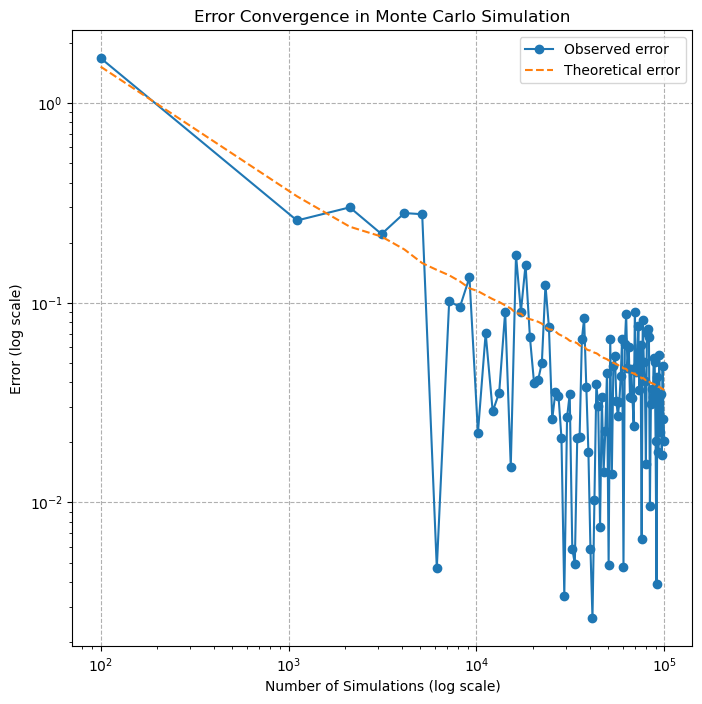

In [32]:
plt.figure(figsize=(8, 8))
plt.loglog(num_sim_arr, error_observed, linestyle='-', marker="o", label="Observed error")
plt.loglog(num_sim_arr, error_theo_arr, linestyle='--', label="Theoretical error")
plt.xlabel("Number of Simulations (log scale)")
plt.ylabel("Error (log scale)")
plt.title("Error Convergence in Monte Carlo Simulation")
plt.legend()
plt.grid(True, linestyle="--")
plt.show()

The figure indicates that the error is approximately $ \frac{e^{-rT} \sigma_{\mathrm{payoff}}}{\sqrt{N}}$, confirming the expected Monte Carlo convergence behavior.

## Conclusions:

- The Monte Carlo error follows the expected theoretical behavior, scaling as $1/\sqrt{N}$.
- The log-log plot confirms that the error is proportional to $ \frac{e^{-rT} \sigma_{\mathrm{payoff}}}{\sqrt{N}} $.
- This project validates the theoretical Monte Carlo convergence rate and highlights the trade-off between accuracy and computational cost.
- While Monte Carlo is flexible for complex options, Black-Scholes remains the most efficient method for European options due to its closed-form solution.